# Mini-Projeto 2 - Classificação de Dígitos MNIST

Neste notebook eu montei um pipeline de análise preditiva para classificar dígitos manuscritos usando a base MNIST. A ideia é carregar os dados, entender a estrutura das imagens, treinar três modelos diferentes e comparar os resultados.

In [1]:
import importlib
from IPython.display import Markdown, display

import mini_projeto_2 as mp
importlib.reload(mp)

mp.preparar_pastas()

## Fase 1 - Carregamento e análise exploratória

Primeiro eu carrego o MNIST e observo o tamanho da base. Também verifico se os dígitos estão bem distribuídos e mostro exemplos visuais de cada número.

Baixando o dataset MNIST...


Finalizou o processo de baixar o dataset MNIST!
Formato de X: (70000, 784)
Formato de y: (70000,)

Distribuição das classes:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


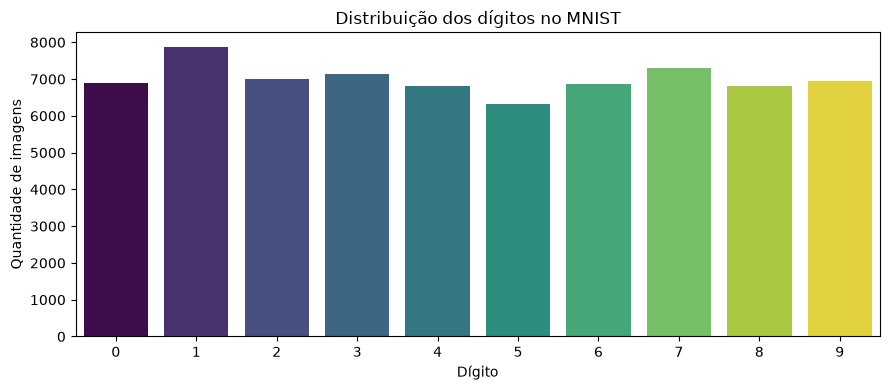

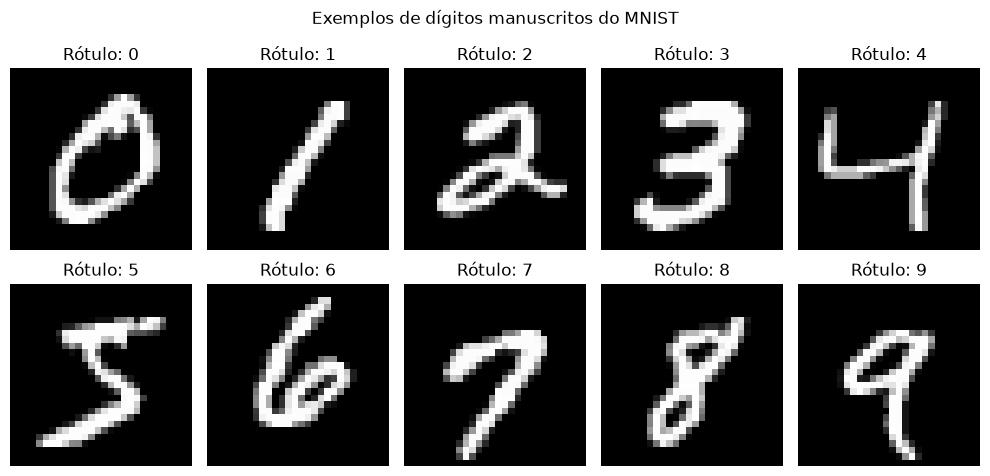

In [2]:
X, y = mp.carregar_mnist()

distribuicao_base = mp.mostrar_distribuicao_classes(
    y,
    nome_arquivo="distribuicao_classes_base_completa.png"
)

mp.mostrar_grade_digitos(X, y)

Cada imagem do MNIST tem 28 por 28 pixels. No modelo, essa imagem é representada como uma linha com 784 colunas, porque 28 x 28 = 784. Cada coluna guarda a intensidade de um pixel, indo de 0 para regiões escuras até 255 para regiões mais claras.

## Amostra para testes no VS Code

Para facilitar os testes, deixei uma amostra rápida ativada no arquivo Python. Assim o projeto roda mais rápido enquanto estou desenvolvendo. Se eu quiser usar a base completa, basta trocar `USAR_AMOSTRA_RAPIDA` para `False`.


Distribuição das classes:
0    1000
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
8    1000
9    1000
Name: count, dtype: int64


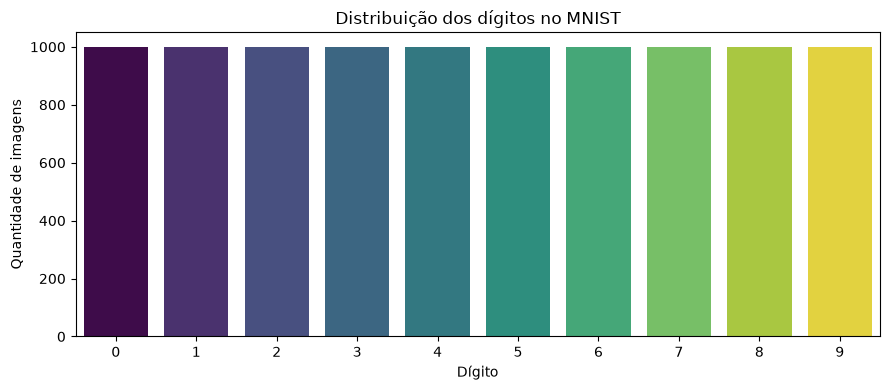

In [3]:
if mp.USAR_AMOSTRA_RAPIDA:
    X_modelo, y_modelo = mp.criar_amostra_estratificada(
        X,
        y,
        n_por_classe=mp.AMOSTRA_POR_CLASSE
    )
else:
    X_modelo, y_modelo = X, y

distribuicao_modelagem = mp.mostrar_distribuicao_classes(
    y_modelo,
    nome_arquivo="distribuicao_classes_modelagem.png"
)

## Fase 2 - Pré-processamento e divisão dos dados

Aqui eu separo a base em treino, validação e teste usando estratificação. Depois faço a normalização dos pixels dividindo por 255, deixando os valores entre 0 e 1.

In [4]:
X_treino, X_validacao, X_teste, y_treino, y_validacao, y_teste = mp.dividir_e_normalizar(
    X_modelo,
    y_modelo
)


Tamanhos após a divisão:
Treino: 7000 imagens
Validação: 1000 imagens
Teste: 2000 imagens


A normalização é importante porque os modelos trabalham melhor quando os valores ficam em uma escala parecida. Como os pixels iam de 0 a 255, dividir por 255 deixa tudo no intervalo de 0 até 1.

## Fase 3 - Treinamento dos três modelos

Nesta etapa eu treino KNN, Random Forest e MLP. Para cada modelo, testo configurações diferentes e escolho a melhor usando o conjunto de validação.

In [5]:
melhores_modelos, historico_df = mp.treinar_modelos(
    X_treino,
    y_treino,
    X_validacao,
    y_validacao
)

historico_df.round(2)


Treinando KNN...


KNN {'n_neighbors': 3, 'weights': 'uniform'} | treino: 97.44% | validação: 94.20% | tempo: 0.0s


KNN {'n_neighbors': 5, 'weights': 'distance'} | treino: 100.00% | validação: 94.60% | tempo: 0.0s


KNN {'n_neighbors': 7, 'weights': 'distance'} | treino: 100.00% | validação: 94.10% | tempo: 0.0s

Treinando Random Forest...


Random Forest {'n_estimators': 80, 'max_depth': 12} | treino: 99.83% | validação: 93.60% | tempo: 0.2s


...

Random Forest {'n_estimators': 120, 'max_depth': None} | treino: 100.00% | validação: 93.70% | tempo: 0.4s

Treinando MLP...


MLP {'hidden_layer_sizes': (64,), 'alpha': 0.0001, 'learning_rate_init': 0.001} | treino: 98.37% | validação: 93.40% | tempo: 1.5s


MLP {'hidden_layer_sizes': (128,), 'alpha': 0.0001, 'learning_rate_init': 0.001} | treino: 98.84% | validação: 93.80% | tempo: 4.9s


MLP {'hidden_layer_sizes': (128, 64), 'alpha': 0.0005, 'learning_rate_init': 0.001} | treino: 99.01% | validação: 94.00% | tempo: 4.8s


,modelo,parametros,acuracia_treino_%,acuracia_validacao_%,tempo_treino_segundos
0,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",97.44,94.2,0.00
1,KNN,"{'n_neighbors': 5, 'weights': 'distance'}",100.00,94.6,0.01
2,KNN,"{'n_neighbors': 7, 'weights': 'distance'}",100.00,94.1,0.00
3,Random Forest,"{'n_estimators': 80, 'max_depth': 12}",99.83,93.6,0.25
4,Random Forest,"{'n_estimators': 120, 'max_depth': 18}",100.00,93.7,0.46
5,Random Forest,"{'n_estimators': 120, 'max_depth': None}",100.00,93.7,0.39
6,MLP,"{'hidden_layer_sizes': (64,), 'alpha': 0.0001,...",98.37,93.4,1.50
7,MLP,"{'hidden_layer_sizes': (128,), 'alpha': 0.0001...",98.84,93.8,4.88
8,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0...",99.01,94.0,4.79


Eu usei o conjunto de validação para comparar as configurações antes de olhar o teste final. Isso ajuda a evitar escolher um modelo só porque ele foi bem em um conjunto que deveria ficar reservado para a avaliação final.

## Fase 4 - Avaliação comparativa

Agora eu avalio os melhores modelos no conjunto de teste. As métricas aparecem em porcentagem e as matrizes de confusão mostram onde cada modelo acertou ou errou.

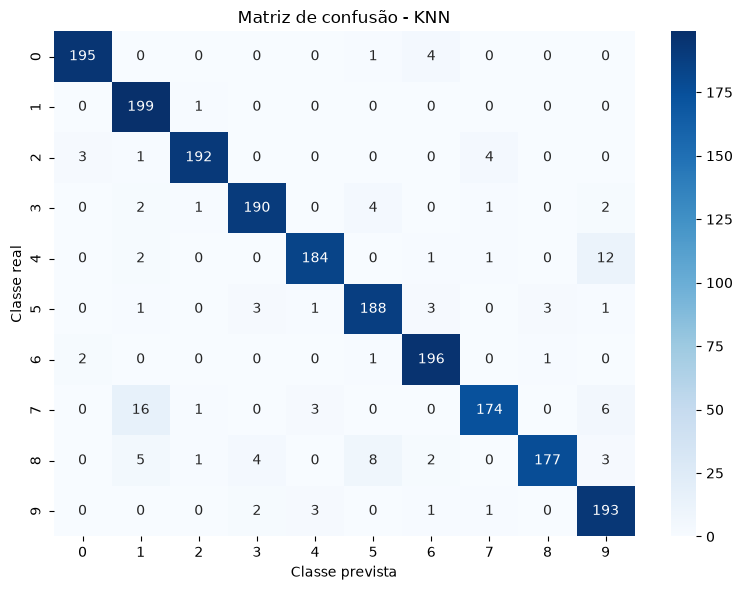

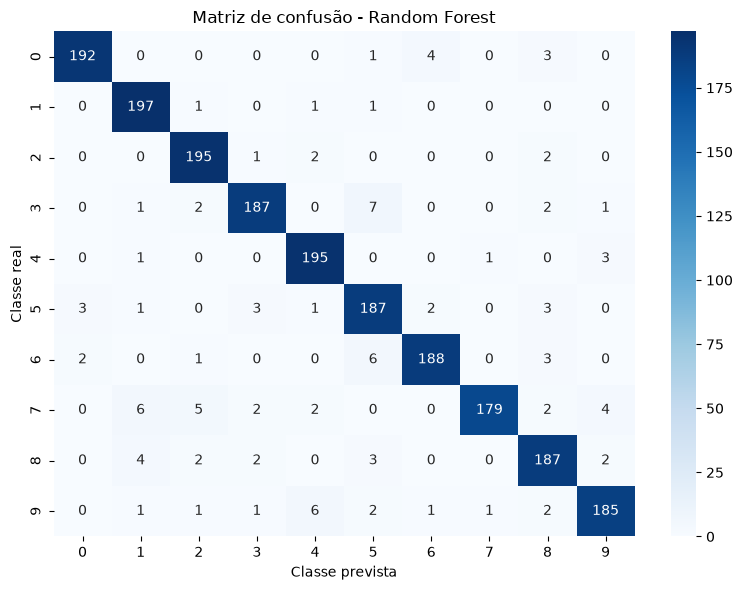

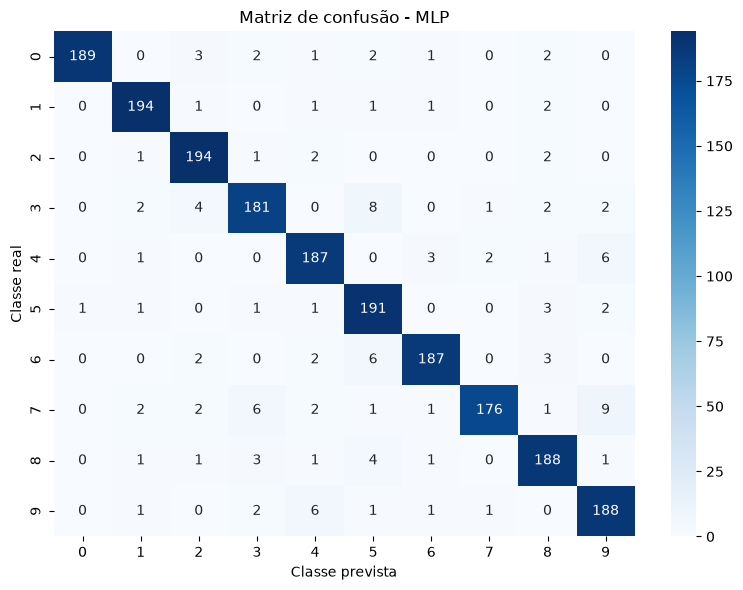


Tabela comparativa final:
          modelo                                         parametros  \
1  Random Forest             {'n_estimators': 120, 'max_depth': 18}   
0            KNN          {'n_neighbors': 5, 'weights': 'distance'}   
2            MLP  {'hidden_layer_sizes': (128, 64), 'alpha': 0.0...   

   acuracia_%  precisao_ponderada_%  recall_ponderado_%  f1_ponderado_%  \
1       94.60                 94.68               94.60           94.60   
0       94.40                 94.59               94.40           94.39   
2       93.75                 93.87               93.75           93.76   

   tempo_predicao_segundos  
1                     0.04  
0                     0.16  
2                     0.01  


,modelo,parametros,acuracia_%,precisao_ponderada_%,recall_ponderado_%,f1_ponderado_%,tempo_predicao_segundos
1,Random Forest,"{'n_estimators': 120, 'max_depth': 18}",94.60,94.68,94.60,94.60,0.04
0,KNN,"{'n_neighbors': 5, 'weights': 'distance'}",94.40,94.59,94.40,94.39,0.16
2,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0...",93.75,93.87,93.75,93.76,0.01


In [6]:
comparativo, predicoes = mp.avaliar_modelos(melhores_modelos, X_teste, y_teste)
comparativo.round(2)

In [7]:
melhor_nome = comparativo.iloc[0]["modelo"]
digito_real, digito_previsto, total = mp.identificar_maior_confusao(
    y_teste,
    predicoes[melhor_nome]
)

display(Markdown(
    f"O melhor modelo foi **{melhor_nome}**. "
    f"A maior confusão apareceu quando o dígito **{digito_real}** foi previsto como **{digito_previsto}**, "
    f"com **{total}** casos. Isso mostra que alguns dígitos têm formatos parecidos e podem gerar erro mesmo quando o resultado geral é bom."
))

O melhor modelo foi **Random Forest**. A maior confusão apareceu quando o dígito **3** foi previsto como **5**, com **7** casos. Isso mostra que alguns dígitos têm formatos parecidos e podem gerar erro mesmo quando o resultado geral é bom.

## Fase 5 - Robustez com classes ocultas

Nesta parte eu escondo os dígitos 4 e 7 do treino. Depois testo o modelo somente com essas classes para ver como ele reage quando recebe imagens que nunca viu durante o aprendizado.


Treinando teste OOD com o modelo KNN, ocultando (4, 7).


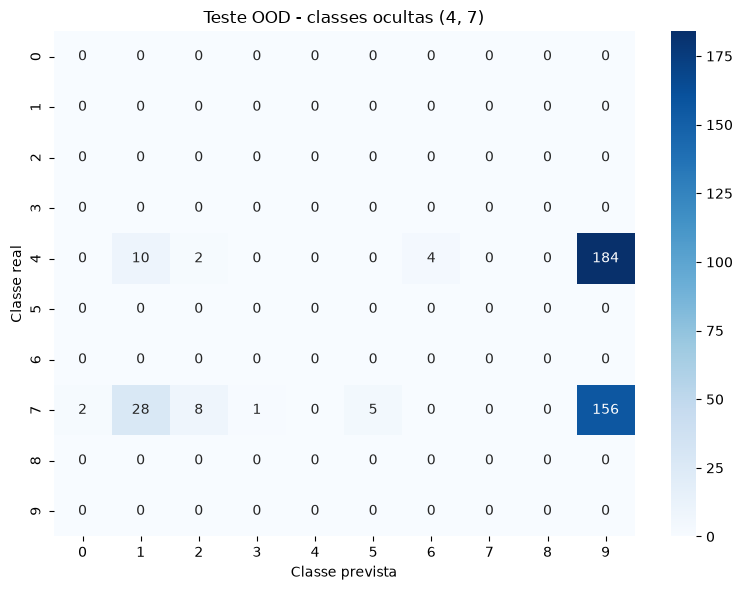


Classes que o modelo usou para tentar classificar os dígitos ocultos:
0      2
1     38
2     10
3      1
5      5
6      4
9    340
Name: count, dtype: int64
Certeza média nas previsões OOD: 90.37%


In [8]:
resultado_ood = mp.treinar_teste_ood(
    X_treino,
    y_treino,
    X_teste,
    y_teste,
    melhores_modelos,
    classes_ocultas=(4, 7)
)

In [9]:
texto_ood = (
    "Quando o modelo recebe dígitos que não apareceram no treino, ele ainda tenta encaixar a imagem em alguma classe conhecida. "
    "Isso mostra a falsa certeza: o modelo pode responder com confiança mesmo quando não aprendeu aquela classe."
)

if resultado_ood["certeza_media_%"] is not None:
    texto_ood += f" Neste teste, a certeza média foi de {resultado_ood['certeza_media_%']:.2f}%."

display(Markdown(texto_ood))

Quando o modelo recebe dígitos que não apareceram no treino, ele ainda tenta encaixar a imagem em alguma classe conhecida. Isso mostra a falsa certeza: o modelo pode responder com confiança mesmo quando não aprendeu aquela classe. Neste teste, a certeza média foi de 90.37%.

## Fase 5.3 - Teste com imagens próprias

Para testar uma imagem minha, eu posso colocar arquivos na pasta `data/minhas_imagens`. O código converte a imagem para escala de cinza, ajusta para 28x28 pixels e usa o melhor modelo para fazer a previsão.


Melhor modelo salvo em: C:\Users\lugul\Downloads\SCTEC\Mini-Projeto-2\models\melhor_modelo_mnist.joblib


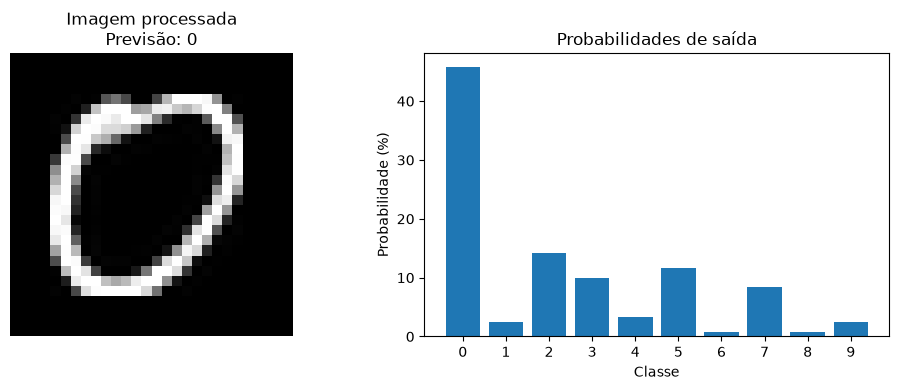

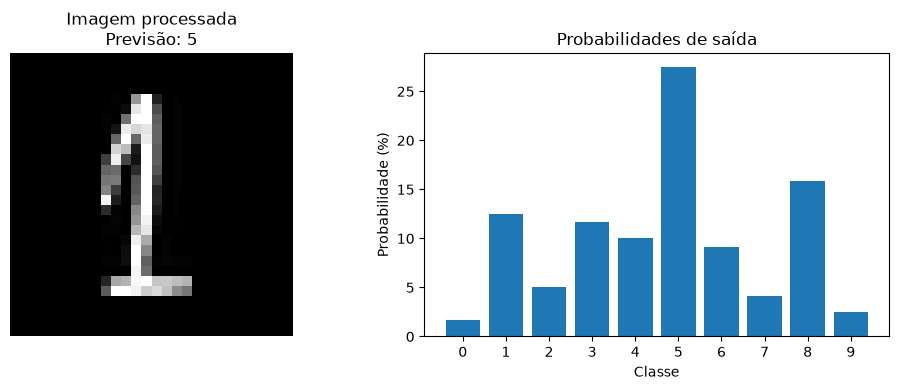

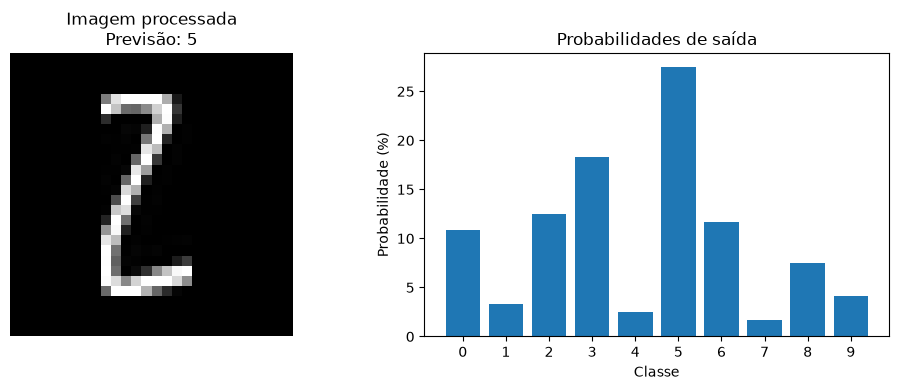

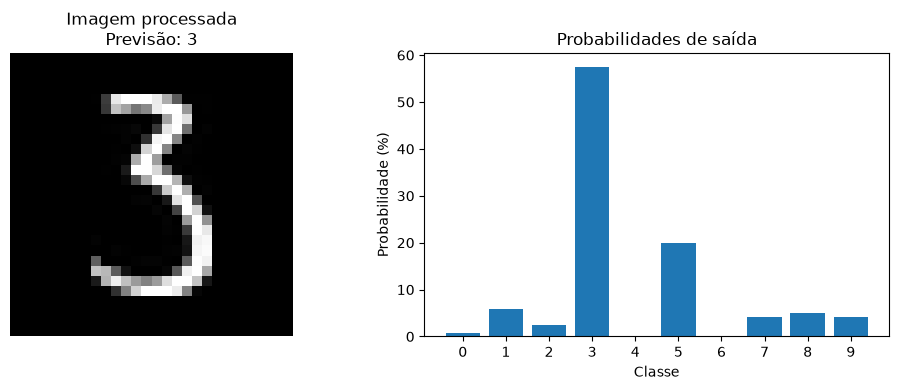

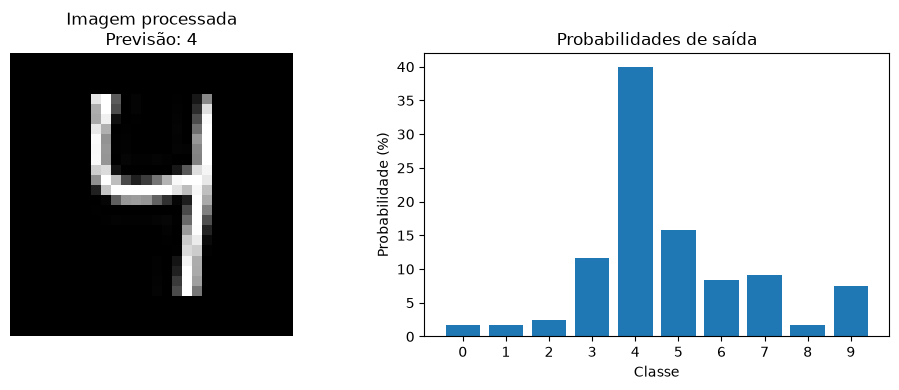

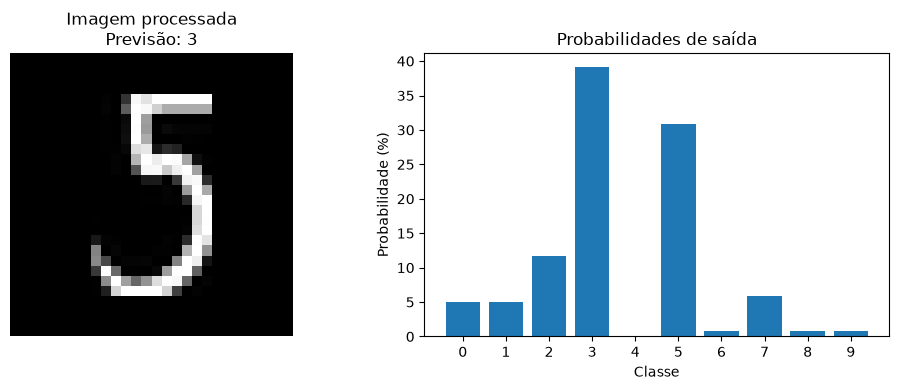

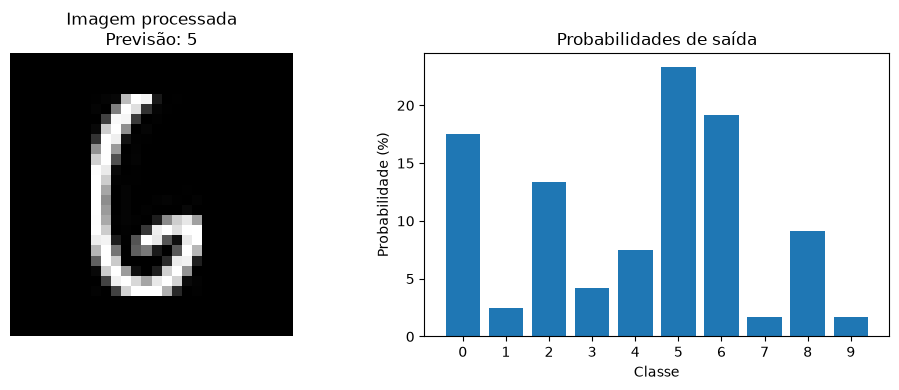

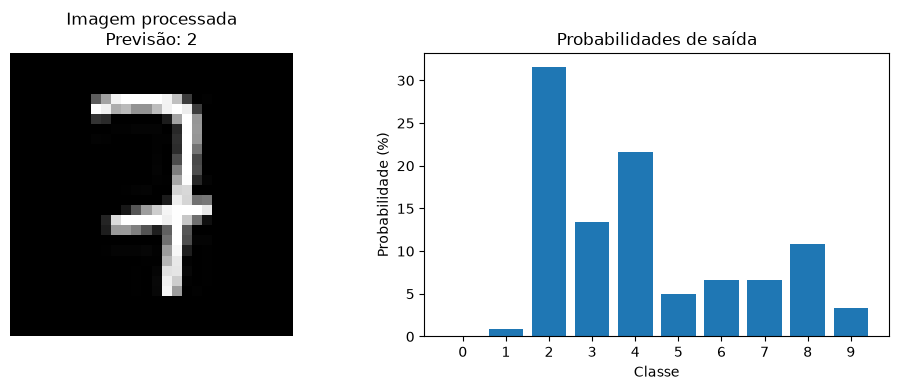

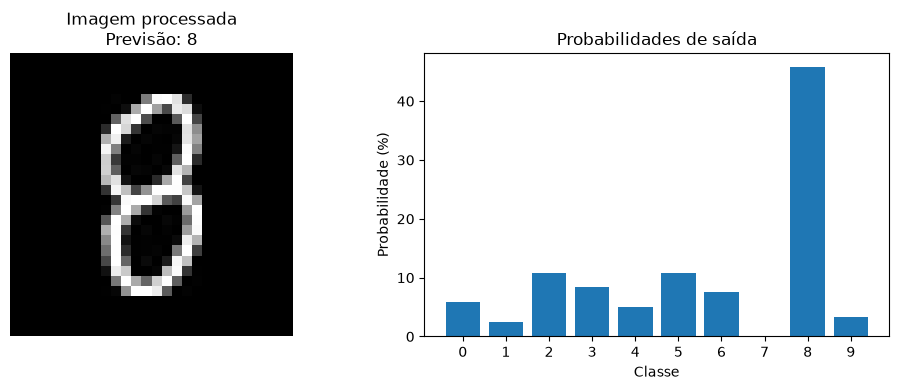

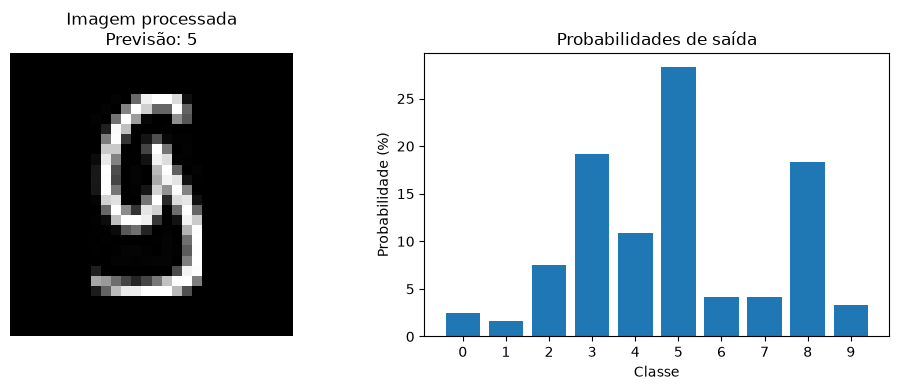


Previsões das imagens próprias:
        arquivo  predicao
0  digito0.jpeg         0
1  digito1.jpeg         5
2  digito2.jpeg         5
3  digito3.jpeg         3
4  digito4.jpeg         4
5  digito5.jpeg         3
6  digito6.jpeg         5
7  digito7.jpeg         2
8  digito8.jpeg         8
9  digito9.jpeg         5


,arquivo,predicao
0,digito0.jpeg,0
1,digito1.jpeg,5
2,digito2.jpeg,5
3,digito3.jpeg,3
4,digito4.jpeg,4
5,digito5.jpeg,3
6,digito6.jpeg,5
7,digito7.jpeg,2
8,digito8.jpeg,8
9,digito9.jpeg,5


In [10]:
caminho_modelo = mp.salvar_melhor_modelo(melhores_modelos, comparativo)
previsoes_imagens_proprias = mp.testar_imagens_proprias(
    melhores_modelos[melhor_nome]["modelo"]
)

previsoes_imagens_proprias

## Conclusão

O modelo escolhido deve ser o que apresentar melhor equilíbrio entre acurácia no teste e tempo de execução. Neste projeto, eu comparo os três modelos com as mesmas métricas para justificar a escolha final, em vez de olhar apenas um resultado isolado.